In [1]:
import atom
import matplotlib.pyplot as plt
import mrcfile
import pdbtools
import potential
import propagators
import torch
from tqdm import tqdm
from plotting_tools import plot3d, plot_slices

%load_ext autoreload
%autoreload 2

## Plotting functions

## Download PDB file

In [4]:
folder = './pdb-data/'
filename = pdbtools.fetch_pdb_file("7a4m-aligned", output=folder)
filename

PDB file saved to: ./pdb-data/5mac.cif


'./pdb-data/5mac.cif'

In [2]:
filename = './pdb-data/7a4m-aligned.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [4]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
assemble = False
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename, assemble=assemble)
atomic_numbers.shape, coords.shape

(torch.Size([2891]), torch.Size([24, 2891, 3]))

In [5]:
#stack coordinates to assemble manually
if not assemble:
    stacked_coords = coords[0]
    for i in range(1, coords.shape[0]):
        stacked_coords = torch.concat((stacked_coords, coords[i]), dim=0)
    stacked_atomic_numbers = atomic_numbers.repeat(coords.shape[0])
    atomic_numbers = stacked_atomic_numbers
    coords = stacked_coords

In [6]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'S', 'N', 'H', 'C', 'FE', 'ZN', 'O'}


In [7]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Compute volumetric potential from PDB (2D Projection, Snap)

In [8]:
dx = 0.56875
n = 480
super_sampling_factor = 4
vol_snapped_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-2d",
)

69384it [00:07, 9030.15it/s]


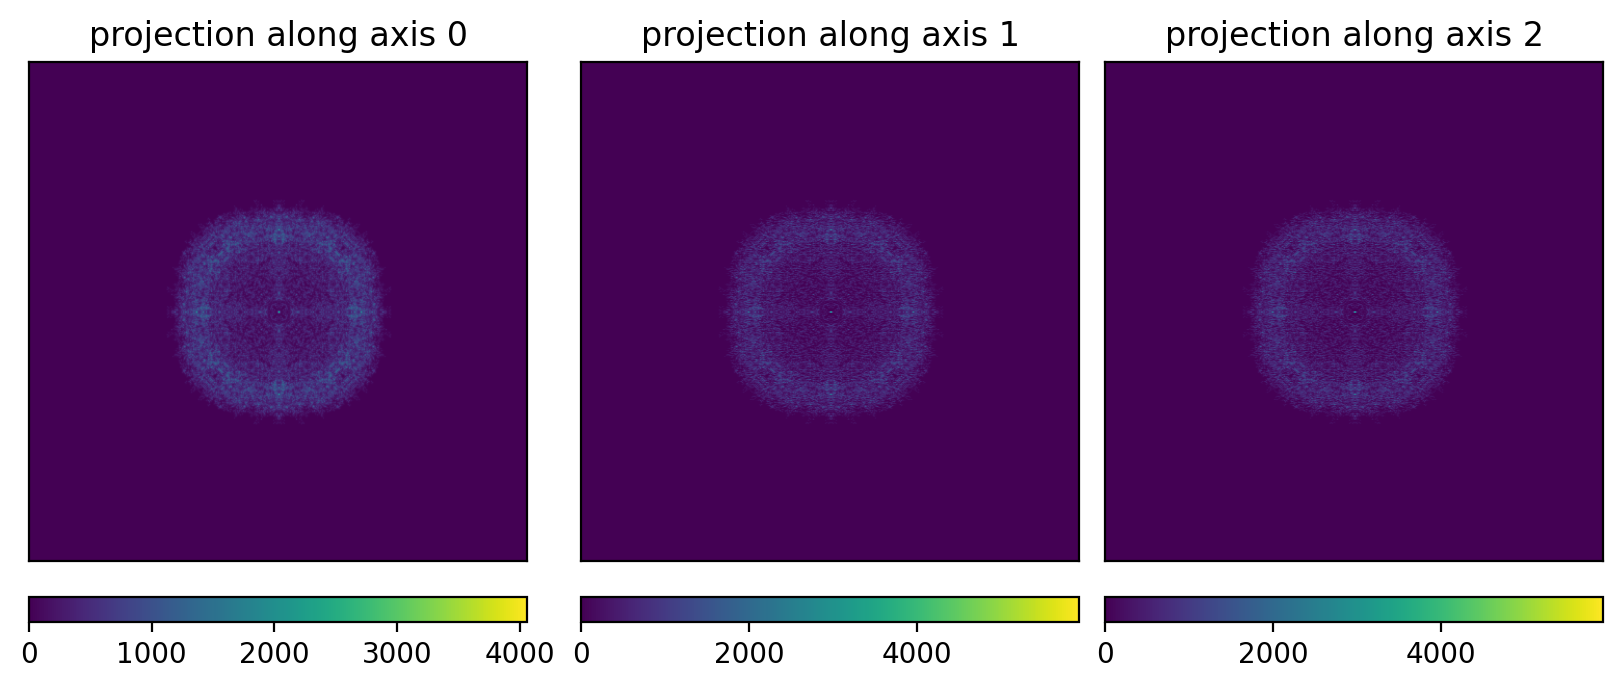

In [9]:
plot3d(vol_snapped_2d)

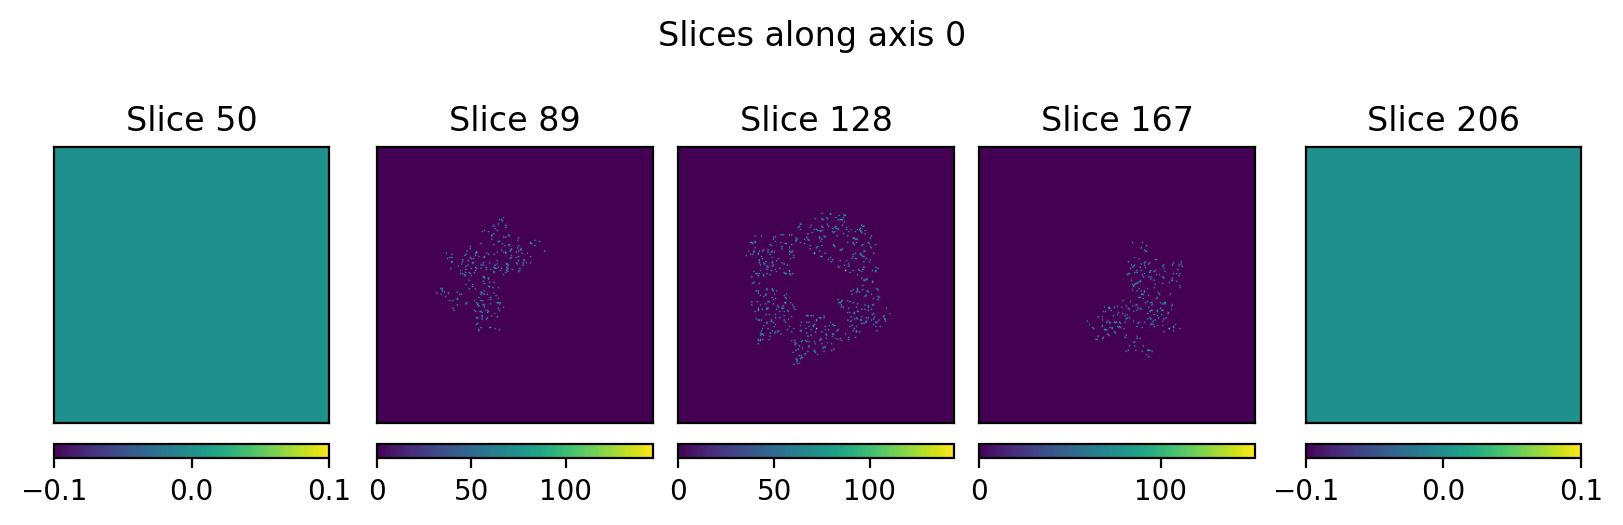

In [11]:
start_idx = 50
plot_slices(vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap)

In [28]:
vol_snapped_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

69384it [00:08, 8277.41it/s]


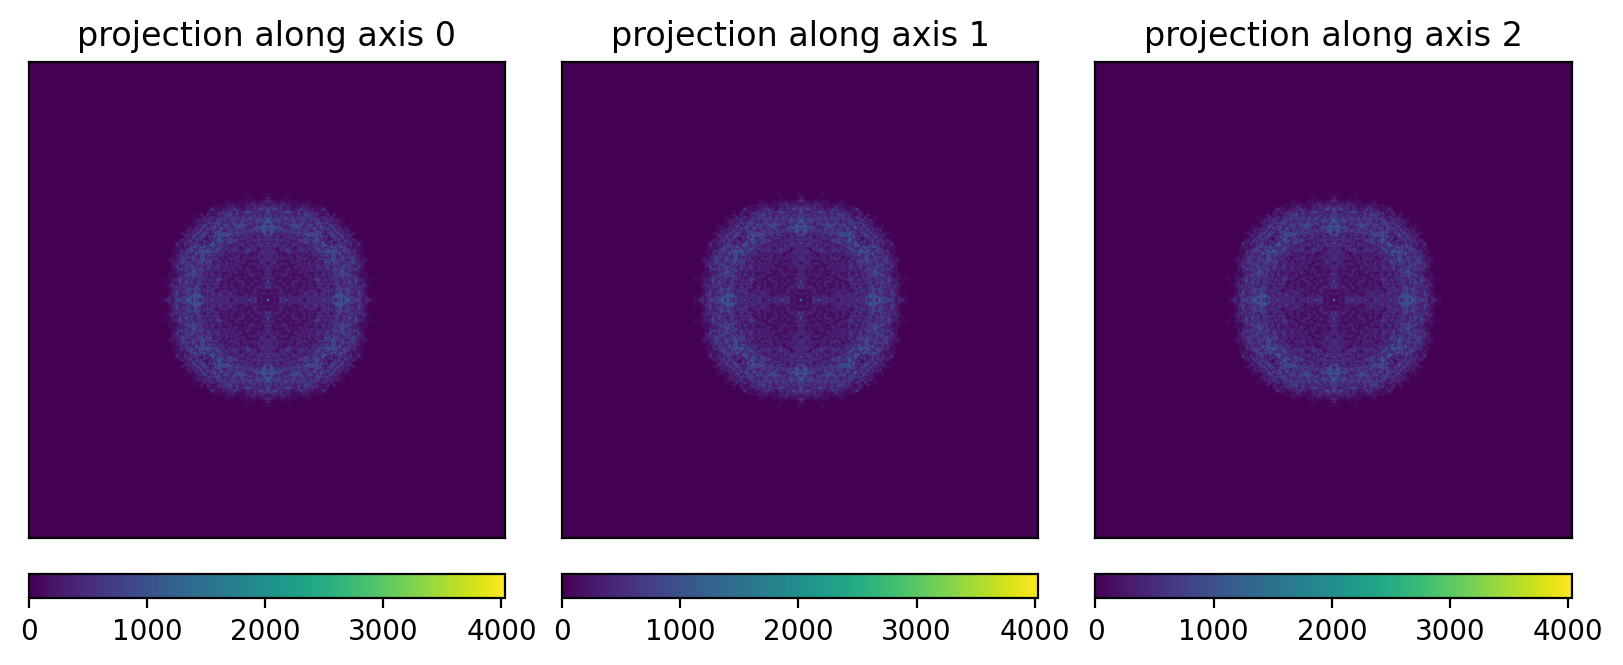

In [29]:
plot3d(vol_snapped_3d)

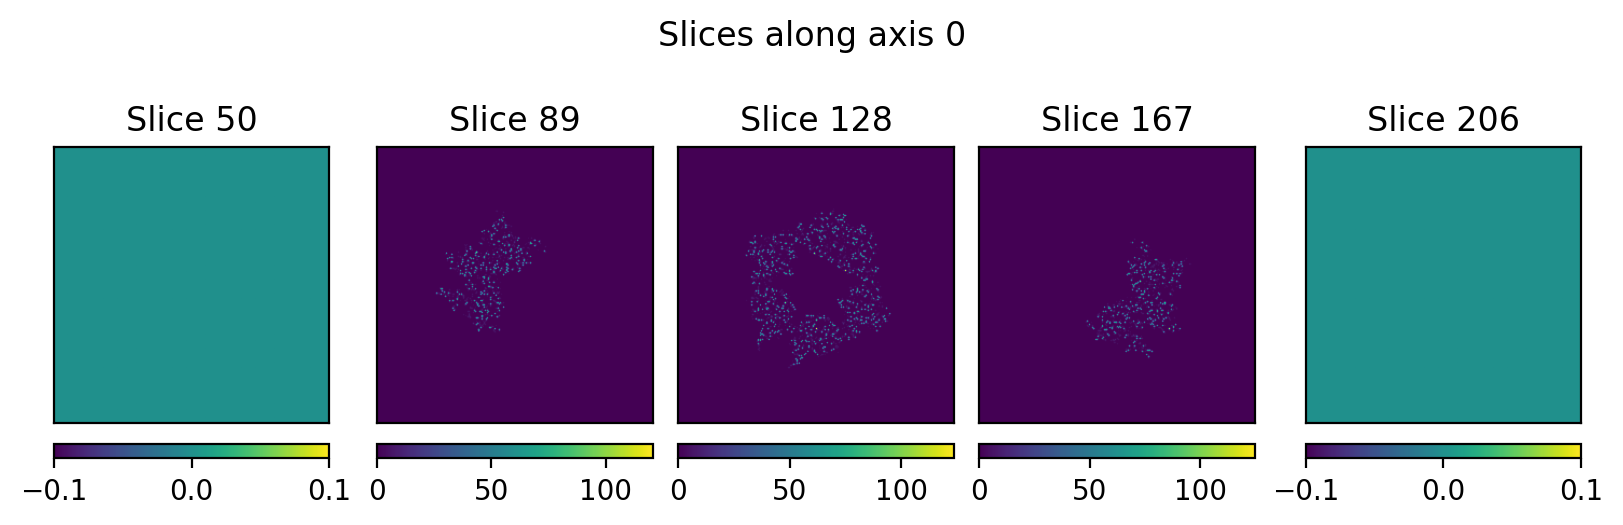

In [14]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (2D Projection, snap-in-z only)

In [15]:
vol_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="2d",
)

37866it [02:16, 276.62it/s]


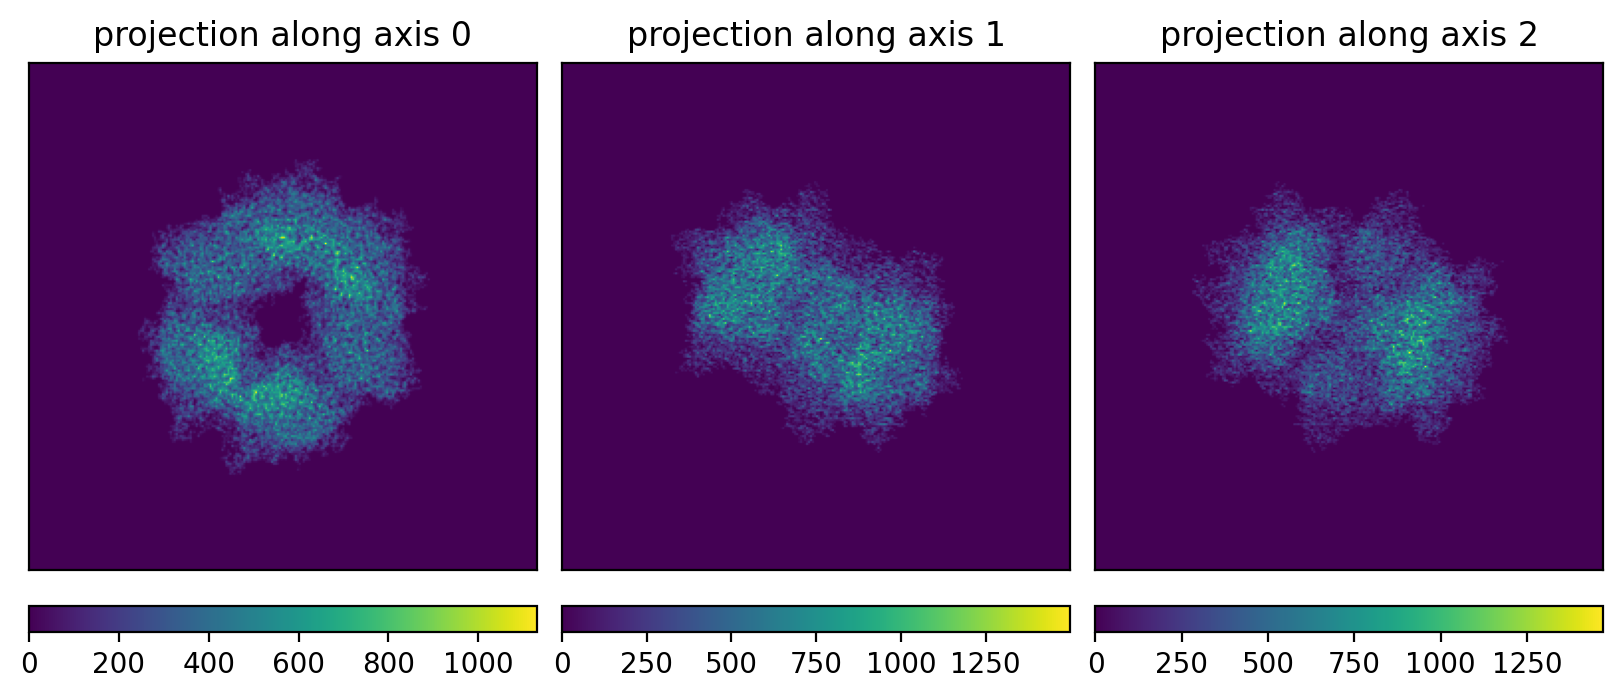

In [16]:
plot3d(vol_2d)

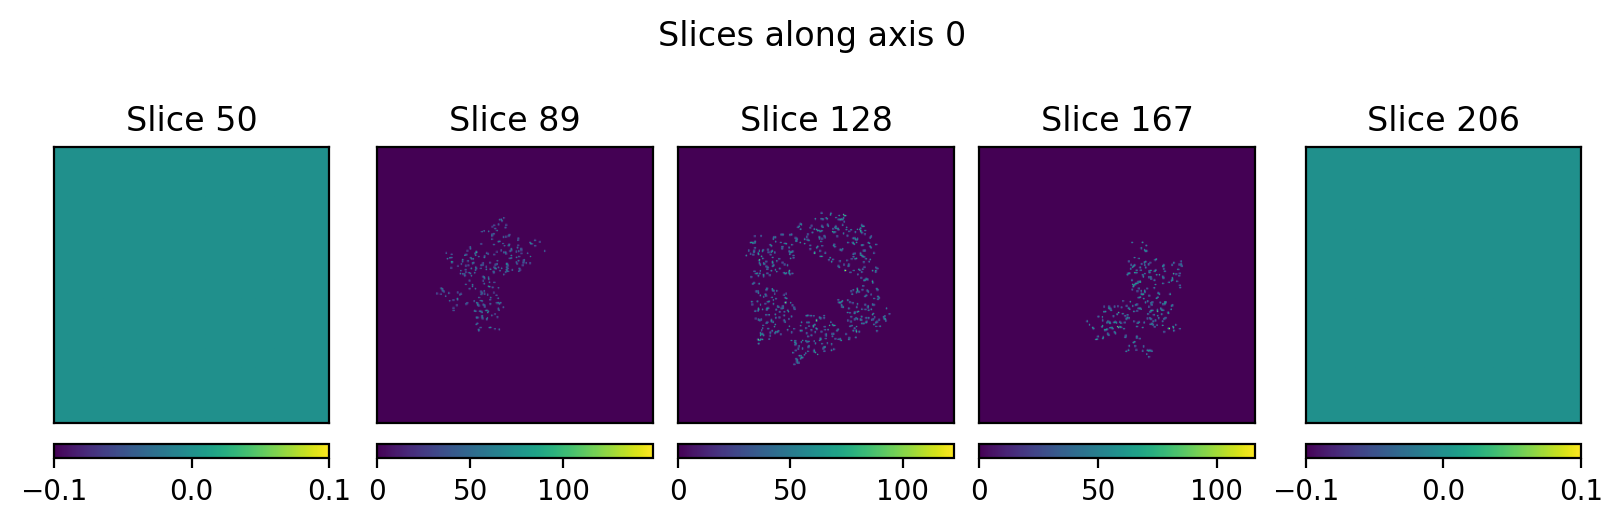

In [17]:
start_idx = 50
plot_slices(vol_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, no-snap)

In [10]:
vol_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="3d",
)

69384it [04:39, 248.21it/s]


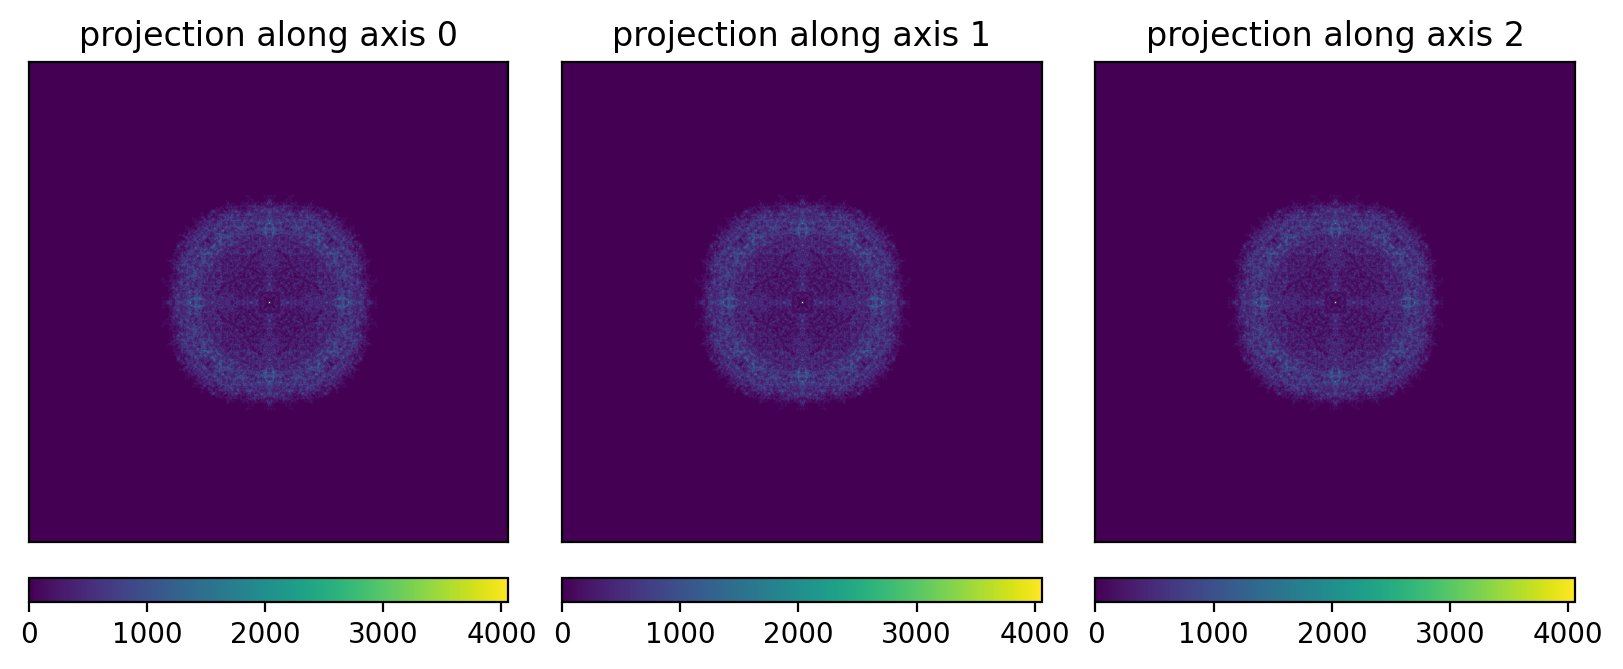

In [11]:
plot3d(vol_3d)

In [12]:
with mrcfile.new('/scratch/loh/joel/jian-apoferritin/7a4m-cryosim.mrc', overwrite=True) as mrc:
    mrc.set_data(vol_3d.type(torch.float32).numpy())
    mrc.voxel_size = dx

## Compare error between snap and no-snap

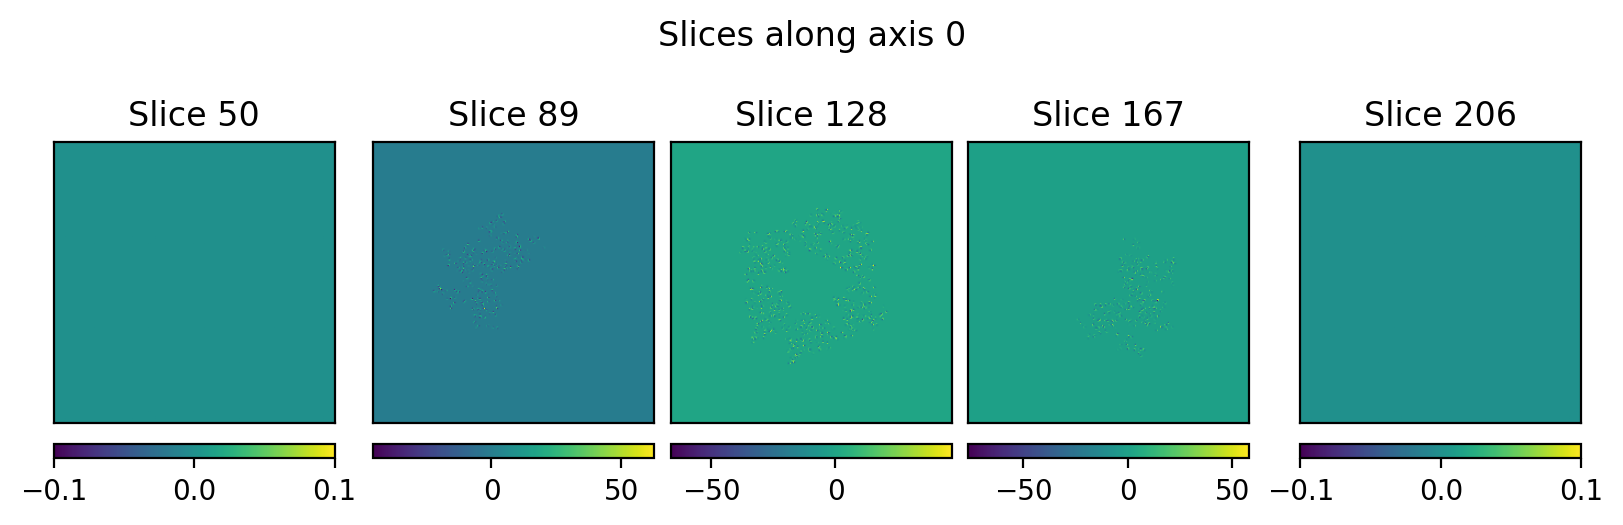

In [20]:
start_idx = 50
plot_slices(vol_2d - vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

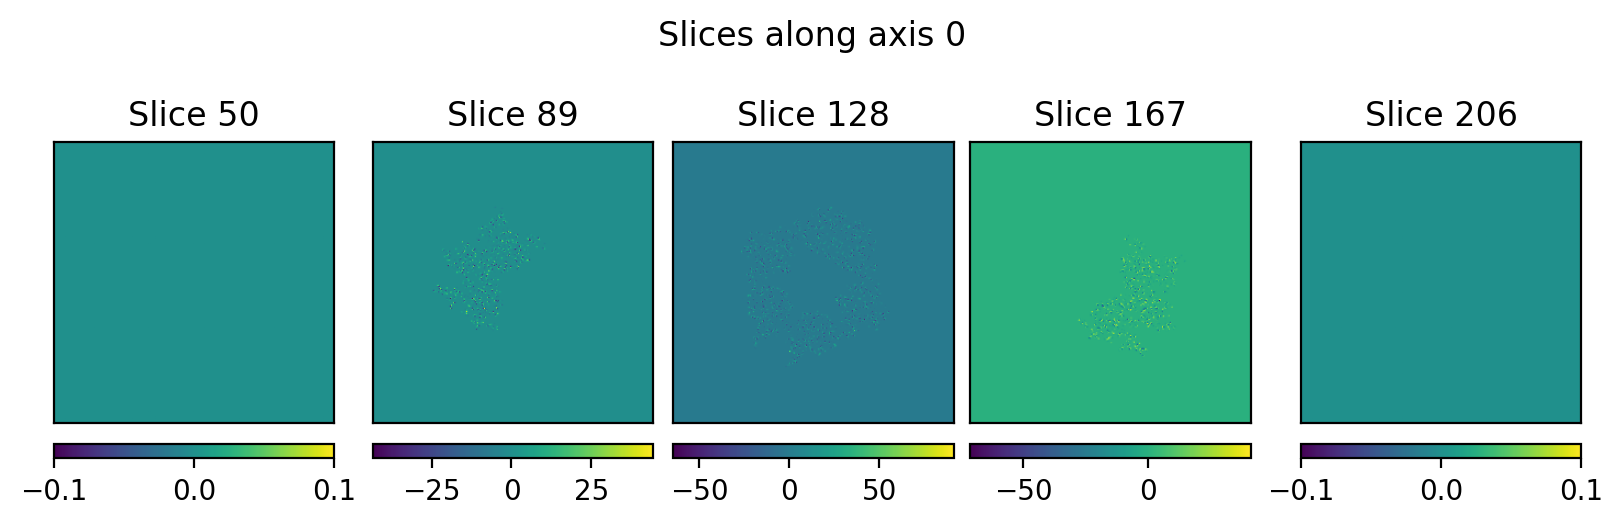

In [21]:
start_idx = 50
plot_slices(vol_3d - vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Solvate

In [299]:
ice_atomic_numbers, ice_coordinates = ice.volume_of_ice(n_xyz=(n,n,n), d_xyz=(dx,dx,dx))

527178


In [300]:
super_sampling_factor = 4
ice_vol_3d = potential.build_potential_volume(
    ice_atomic_numbers,
    ice_coordinates,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=31,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

1581534it [02:55, 9010.26it/s]


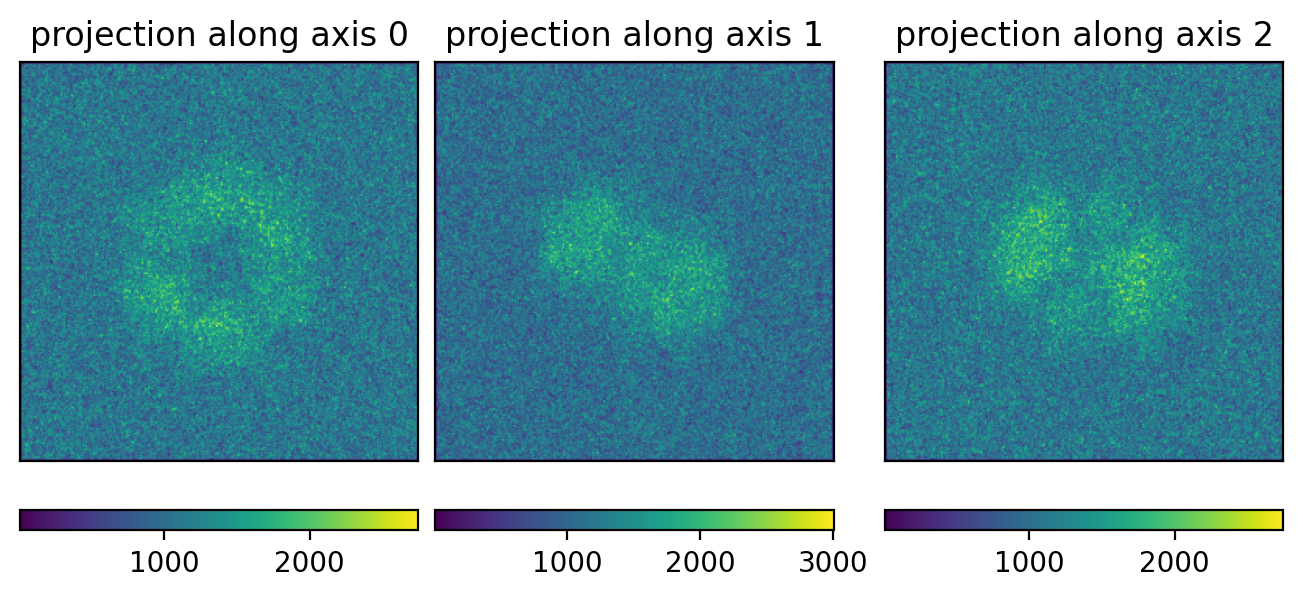

In [301]:
plot3d(ice_vol_3d + vol_3d)

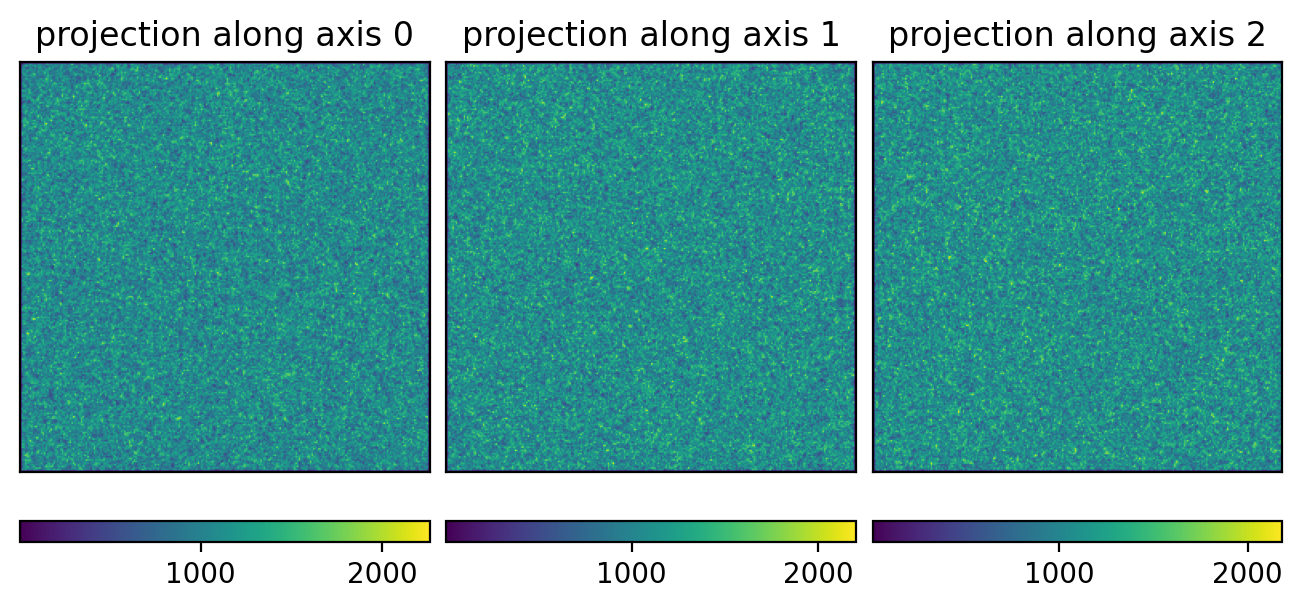

In [302]:
plot3d(ice_vol_3d)

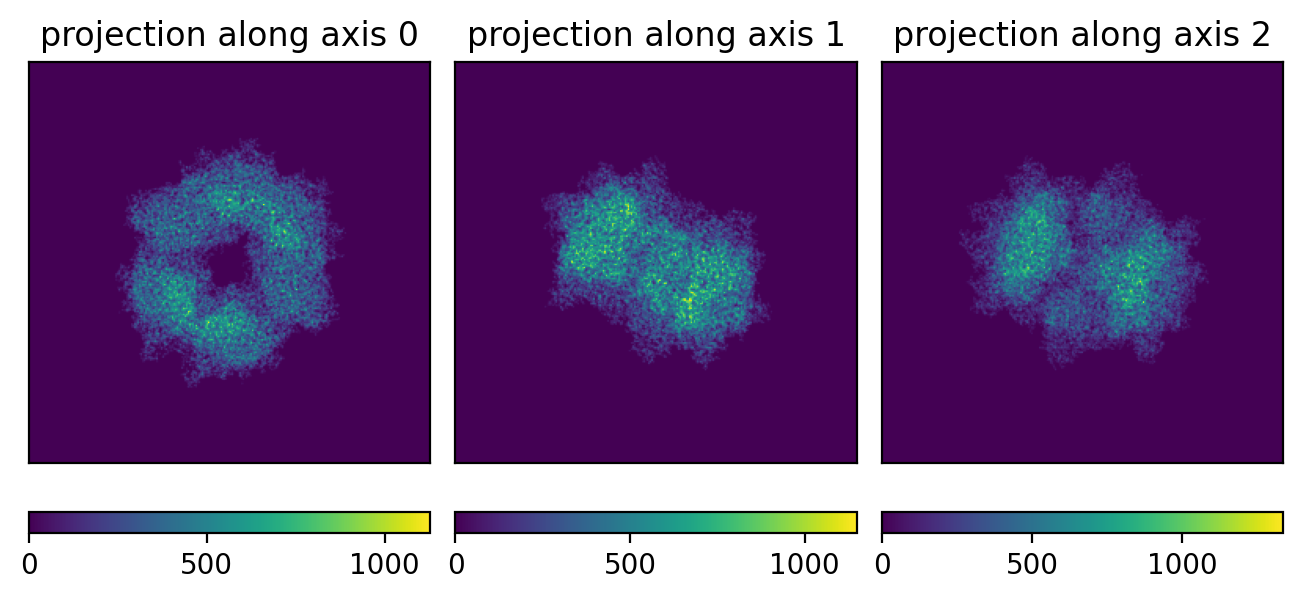

In [303]:
plot3d(vol_3d)